<a href="https://colab.research.google.com/github/mariaeduardasouzabranco/AulaGitHub/blob/main/aula5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula prática: preços de apartamentos à venda em São Paulo
**Regressão linear · matriz de correlação · formulário interativo**

Vamos estimar preços de venda em **R$** com dados reais de anúncios de apartamentos. Compararemos a média do treino, uma regressão apenas com área e outra com características do apartamento e bairro.

**No Colab:** execute as células na ordem e envie **Apartamentos_SP_Original.xlsx** quando solicitado. Não precisa de GPU.

**Fonte:** [Kaggle — Apartamentos à venda na cidade de São Paulo](https://www.kaggle.com/datasets/jlgrego/apartamentos-venda-na-cidade-de-sao-paulo-sp). O Excel original se chama `dados_wgs.xlsx`; o arquivo fornecido tem apenas o nome alterado, sem mudanças nos dados.

A publicação foi atualizada em abril de 2023; essa data não comprova a data exata da coleta. São preços anunciados históricos, não preços de negócios concluídos ou uma avaliação atual.

## 1. Carregar e conhecer a base
São **2.499 apartamentos e 26 colunas** no arquivo original. A base é dedicada a anúncios de venda;

In [2]:
# importar bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from IPython.display import display
from google.colab import files

arquivos = files.upload()
nome_arquivo = next(iter(arquivos))
brutos = pd.read_excel(nome_arquivo)
print(brutos.shape)
display(brutos.head())

Saving Apartamentos_SP_Original.xlsx to Apartamentos_SP_Original.xlsx
(2499, 26)


,id,valor_total,unit,area_util,quartos,vagas,condominio,suites,banheiros,piscina,academia,quadra,endereco,link,bairro,media_bairro,qtd_dados_bairro,media_idh,media_gini,expectativa_vida,renda_percapita,estacao_prox,linha_prox,dist,lat,lon
0,526,189900,5934.38,32,2,1,180.0,0,1,0,1,0,"Rua Juá Mirim, 300 - Cidade Tiradentes, São Pa...",https://www.vivareal.com.br/imovel/apartamento...,JOSE BONIFACIO,4621.488333,36.0,0.697182,0.410909,72.751818,559.668182,SÃO MATEUS,PRATA,6822.823684,-23.583879,-46.417548
1,734,221110,5142.09,43,2,1,250.0,0,1,0,0,1,"Rua Luís Mateus, 100 - Guaianases, São Paulo - SP",https://www.vivareal.com.br/imovel/apartamento...,JOSE BONIFACIO,4621.488333,36.0,0.697182,0.410909,72.751818,559.668182,CORINTHIANS-ITAQUERA,VERMELHA,4682.709841,-23.543535,-46.425492
2,738,219990,5116.05,43,1,1,300.0,0,1,1,0,0,"Estrada Itaquera-Guaianases, 2001 - Guaianases...",https://www.vivareal.com.br/imovel/apartamento...,JOSE BONIFACIO,4621.488333,36.0,0.697182,0.410909,72.751818,559.668182,CORINTHIANS-ITAQUERA,VERMELHA,4579.311123,-23.537339,-46.426823
3,753,219990,5116.05,43,2,1,300.0,0,1,1,0,0,"Estrada Itaquera-Guaianases, 2001 - Guaianases...",https://www.vivareal.com.br/imovel/apartamento...,JOSE BONIFACIO,4621.488333,36.0,0.697182,0.410909,72.751818,559.668182,CORINTHIANS-ITAQUERA,VERMELHA,4579.311123,-23.537339,-46.426823
4,924,220000,5365.85,41,2,1,300.0,0,1,1,1,1,"Rua Ioneji Matsubayashi, 10 - Itaquera, São Pa...",https://www.vivareal.com.br/imovel/apartamento...,JOSE BONIFACIO,4621.488333,36.0,0.697182,0.410909,72.751818,559.668182,CORINTHIANS-ITAQUERA,VERMELHA,3313.918703,-23.557799,-46.443523


In [3]:
# renomear nomes de colunas
dados = brutos.rename(columns={"valor_total": "preco", "area_util": "area"}).copy()
print(dados.dtypes)
display(dados.isna().sum().rename("Ausentes"))
display(dados.head())

id                    int64
preco                 int64
unit                float64
area                  int64
quartos               int64
vagas                 int64
condominio          float64
suites                int64
banheiros             int64
piscina               int64
academia              int64
quadra                int64
endereco             object
link                 object
bairro               object
media_bairro        float64
qtd_dados_bairro    float64
media_idh           float64
media_gini          float64
expectativa_vida    float64
renda_percapita     float64
estacao_prox         object
linha_prox           object
dist                float64
lat                 float64
lon                 float64
dtype: object


,Ausentes
id,0
preco,0
unit,0
area,0
quartos,0
vagas,0
condominio,235
suites,0
banheiros,0
piscina,0


,id,preco,unit,area,quartos,vagas,condominio,suites,banheiros,piscina,academia,quadra,endereco,link,bairro,media_bairro,qtd_dados_bairro,media_idh,media_gini,expectativa_vida,renda_percapita,estacao_prox,linha_prox,dist,lat,lon
0,526,189900,5934.38,32,2,1,180.0,0,1,0,1,0,"Rua Juá Mirim, 300 - Cidade Tiradentes, São Pa...",https://www.vivareal.com.br/imovel/apartamento...,JOSE BONIFACIO,4621.488333,36.0,0.697182,0.410909,72.751818,559.668182,SÃO MATEUS,PRATA,6822.823684,-23.583879,-46.417548
1,734,221110,5142.09,43,2,1,250.0,0,1,0,0,1,"Rua Luís Mateus, 100 - Guaianases, São Paulo - SP",https://www.vivareal.com.br/imovel/apartamento...,JOSE BONIFACIO,4621.488333,36.0,0.697182,0.410909,72.751818,559.668182,CORINTHIANS-ITAQUERA,VERMELHA,4682.709841,-23.543535,-46.425492
2,738,219990,5116.05,43,1,1,300.0,0,1,1,0,0,"Estrada Itaquera-Guaianases, 2001 - Guaianases...",https://www.vivareal.com.br/imovel/apartamento...,JOSE BONIFACIO,4621.488333,36.0,0.697182,0.410909,72.751818,559.668182,CORINTHIANS-ITAQUERA,VERMELHA,4579.311123,-23.537339,-46.426823
3,753,219990,5116.05,43,2,1,300.0,0,1,1,0,0,"Estrada Itaquera-Guaianases, 2001 - Guaianases...",https://www.vivareal.com.br/imovel/apartamento...,JOSE BONIFACIO,4621.488333,36.0,0.697182,0.410909,72.751818,559.668182,CORINTHIANS-ITAQUERA,VERMELHA,4579.311123,-23.537339,-46.426823
4,924,220000,5365.85,41,2,1,300.0,0,1,1,1,1,"Rua Ioneji Matsubayashi, 10 - Itaquera, São Pa...",https://www.vivareal.com.br/imovel/apartamento...,JOSE BONIFACIO,4621.488333,36.0,0.697182,0.410909,72.751818,559.668182,CORINTHIANS-ITAQUERA,VERMELHA,3313.918703,-23.557799,-46.443523


## 2. Preparação e qualidade dos dados
Os preços e características já são numéricos. A base tem **235 valores ausentes de condomínio**, além de valores suspeitos como condomínio de R$ 857.000 e 39 vagas.

Regras da aula, definidas antes da avaliação:
1. Exigir preço e área positivos, quartos/banheiros positivos, suítes não negativas e indicadores 0/1.
2. Limitar vagas a 0–10 como recorte didático. Isso exclui registros fora do escopo sem afirmar que todo valor maior é erro.
3. Tratar condomínio fora de R$ 0–10.000 como não confiável, deixando ausente. Não tentaremos adivinhar a unidade ou corrigir dígitos. Esse limite é uma hipótese didática, que pode deixar de fora condomínios legítimos de alto padrão.
4. Remover duplicatas exatas nas colunas utilizadas e no link.

Não aplicaremos corte por preço máximo. Ausentes de condomínio serão preenchidos **depois da divisão**, usando somente a mediana do treino.

In [4]:
numericas = ["area", "quartos", "banheiros", "suites", "vagas", "condominio", "piscina", "academia", "quadra"]
entradas = numericas + ["bairro"]
etapas = {"Arquivo original": len(dados)}
dados = dados[["link", "preco"] + entradas].copy()
dados["bairro"] = dados["bairro"].astype("string").str.strip()
for coluna in numericas + ["preco"]:
    dados[coluna] = pd.to_numeric(dados[coluna], errors="coerce")

# Condominio é opcional; os demais campos precisam estar preenchidos.
obrigatorias = [coluna for coluna in entradas if coluna != "condominio"] + ["preco", "link"]
dados = dados.dropna(subset=obrigatorias)
validos = (
    (dados["preco"] > 0) & (dados["area"] > 0)
    & (dados["quartos"] > 0) & (dados["banheiros"] > 0)
    & (dados["suites"] >= 0) & dados["vagas"].between(0, 10)
    & dados["bairro"].ne("")
    & dados[["piscina", "academia", "quadra"]].isin([0, 1]).all(axis=1)
)
dados = dados.loc[validos].copy()
etapas["Campos obrigatórios e regras básicas"] = len(dados)

suspeitos = dados["condominio"].notna() & ~dados["condominio"].between(0, 10_000)
print("Condomínios fora da faixa, tratados como ausentes:", int(suspeitos.sum()))
dados.loc[suspeitos, "condominio"] = float("nan")
dados = dados.drop_duplicates().reset_index(drop=True)
etapas["Sem duplicatas exatas"] = len(dados)
display(pd.Series(etapas, name="Registros restantes").to_frame())
display(dados.head())

Condomínios fora da faixa, tratados como ausentes: 4


,Registros restantes
Arquivo original,2499
Campos obrigatórios e regras básicas,2498
Sem duplicatas exatas,2497


,link,preco,area,quartos,banheiros,suites,vagas,condominio,piscina,academia,quadra,bairro
0,https://www.vivareal.com.br/imovel/apartamento...,189900,32,2,1,0,1,180.0,0,1,0,JOSE BONIFACIO
1,https://www.vivareal.com.br/imovel/apartamento...,221110,43,2,1,0,1,250.0,0,0,1,JOSE BONIFACIO
2,https://www.vivareal.com.br/imovel/apartamento...,219990,43,1,1,0,1,300.0,1,0,0,JOSE BONIFACIO
3,https://www.vivareal.com.br/imovel/apartamento...,219990,43,2,1,0,1,300.0,1,0,0,JOSE BONIFACIO
4,https://www.vivareal.com.br/imovel/apartamento...,220000,41,2,1,0,1,300.0,1,1,1,JOSE BONIFACIO


In [5]:
# remover anuncios duplicados (por links iguais)
dados = dados.drop_duplicates(subset="link").copy()
print(len(dados))

2497


## 3. Separar treino e teste
`X` contém as dez características e `y` contém o preço. Reservaremos aproximadamente 20% dos anúncios para teste.

In [8]:
# separar as colunas
X = dados[entradas].copy()
y = dados["preco"]

# dividir a base em treinamento e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

print("Registro de treino: ", len(X_treino))
print("Registro de teste: ", len(X_teste))

Registro de treino:  1997
Registro de teste:  500


## 4. Explorar somente o treino
Agora observamos distribuições e relações sem usar o teste para tomar decisões sobre o modelo.

In [9]:
treino = X_treino.assign(preco=y_treino)
display(treino.describe().round(2))
display(treino["bairro"].value_counts().head(10).rename("Anúncios no treino"))

,area,quartos,banheiros,suites,vagas,condominio,piscina,academia,quadra,preco
count,1997.00,1997.00,1997.00,1997.00,1997.00,1801.00,1997.00,1997.00,1997.00,1997.00
mean,71.54,2.28,1.75,0.65,1.21,604.83,0.37,0.17,0.31,548947.28
std,45.96,0.63,1.03,0.81,0.78,576.54,0.48,0.37,0.46,563869.62
min,22.00,1.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,80000.00
25%,49.00,2.00,1.00,0.00,1.00,349.00,0.00,0.00,0.00,266544.00
50%,60.00,2.00,1.00,1.00,1.00,480.00,0.00,0.00,0.00,380000.00
75%,74.00,3.00,2.00,1.00,1.00,650.00,1.00,0.00,1.00,598000.00
max,640.00,5.00,8.00,4.00,6.00,8800.00,1.00,1.00,1.00,12000000.00


,Anúncios no treino
bairro,
CID LIDER,46
SANTA CECILIA,45
CAMPO GRANDE,41
JOSE BONIFACIO,40
REPUBLICA,38
SACOMA,37
CID DUTRA,37
SAO LUCAS,36
VILA MEDEIROS,33


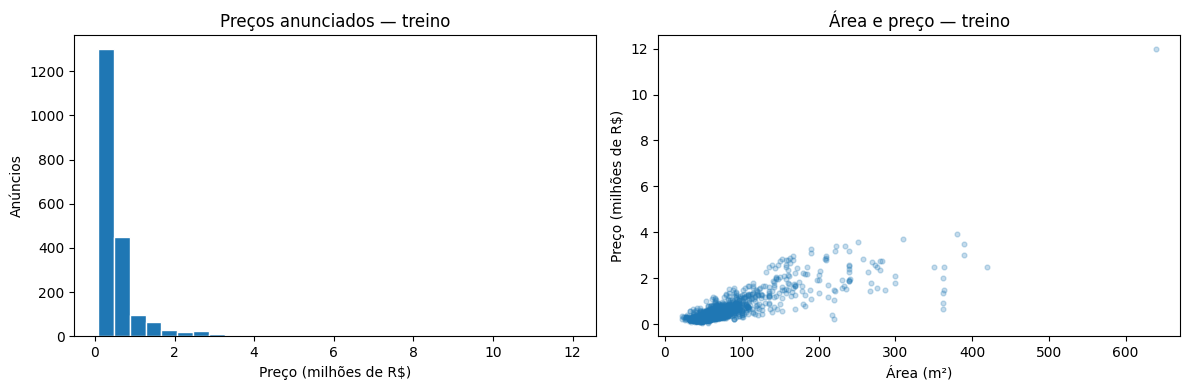

In [10]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 4))
eixos[0].hist(y_treino / 1_000_000, bins=30, edgecolor="white")
eixos[0].set(title="Preços anunciados — treino", xlabel="Preço (milhões de R$)", ylabel="Anúncios")
eixos[1].scatter(X_treino["area"], y_treino / 1_000_000, alpha=0.25, s=12)
eixos[1].set(title="Área e preço — treino", xlabel="Área (m²)", ylabel="Preço (milhões de R$)")
plt.tight_layout()
plt.show()

**Observe:** quais bairros têm mais anúncios? Há apartamentos com áreas semelhantes e preços muito diferentes?

## 5. Matriz de correlação
A matriz inclui as nove características numéricas e o preço. Bairro é categórico e será convertido depois.

- Perto de **+1**: tendem a aumentar juntas.
- Perto de **−1**: uma tende a diminuir quando a outra aumenta.
- Perto de **0**: pouca associação linear, sem descartar outros tipos de relação.

Nos indicadores 0/1, a correlação compara presença e ausência da característica. A diagonal é 1. **Correlação não prova causalidade nem mede sozinha a importância no modelo.**

Nesta exploração, `corr()` usa os pares disponíveis: correlações envolvendo condomínio podem usar menos linhas por causa dos ausentes.

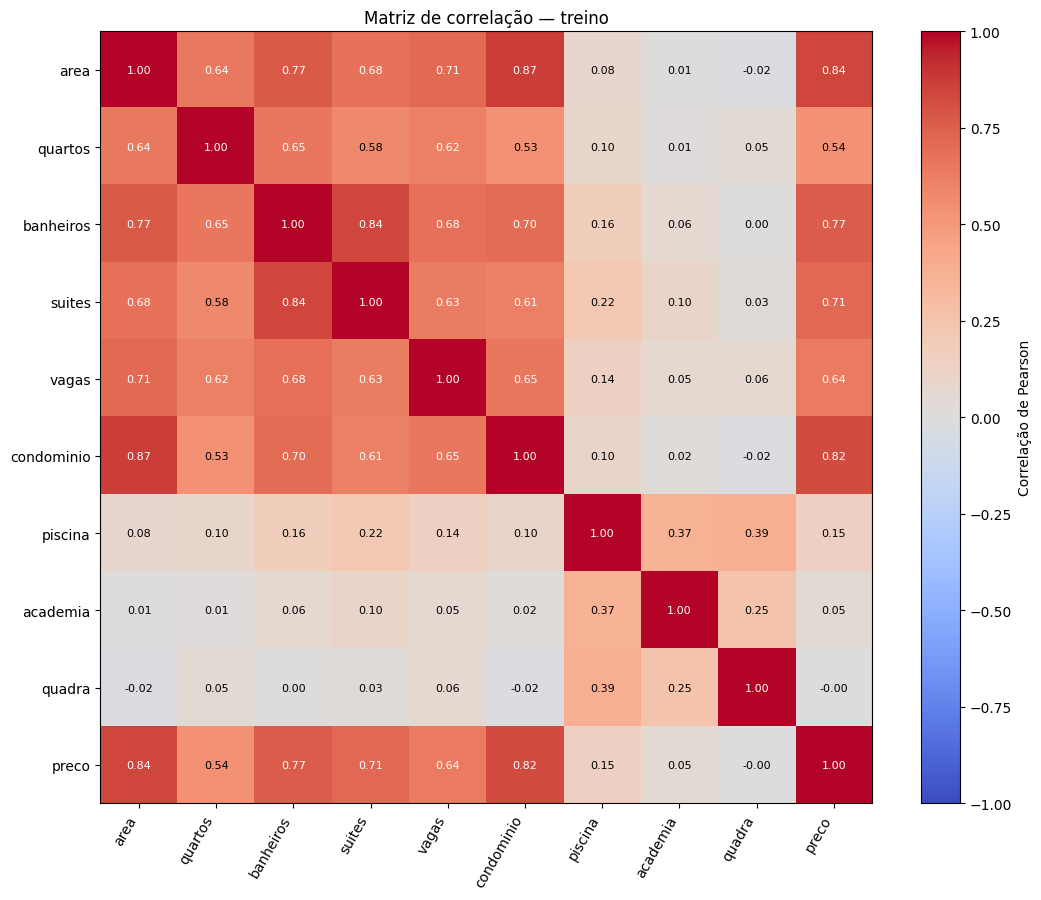

,preco
area,0.84
condominio,0.82
banheiros,0.77
suites,0.71
vagas,0.64
quartos,0.54
piscina,0.15
academia,0.05
quadra,-0.00


In [11]:
correlacao = treino[numericas + ["preco"]].corr()
fig, eixo = plt.subplots(figsize=(11, 9))
imagem = eixo.imshow(correlacao, cmap="coolwarm", vmin=-1, vmax=1)
eixo.set_xticks(range(len(correlacao)), correlacao.columns, rotation=60, ha="right")
eixo.set_yticks(range(len(correlacao)), correlacao.columns)
for linha in range(len(correlacao)):
    for coluna in range(len(correlacao)):
        valor = correlacao.iloc[linha, coluna]
        eixo.text(coluna, linha, f"{valor:.2f}", ha="center", va="center", fontsize=8,
                  color="white" if abs(valor) > 0.6 else "black")
fig.colorbar(imagem, ax=eixo, label="Correlação de Pearson")
eixo.set_title("Matriz de correlação — treino")
plt.tight_layout()
plt.show()
display(correlacao["preco"].drop("preco").sort_values(ascending=False).round(2))

## 6. Preparar as entradas
**Condomínio:** preenchemos os ausentes com a mediana do treino. Usamos esse mesmo número no teste e em novas previsões; calcular a mediana no dataset inteiro usaria informação do teste.

**Bairro:** criamos indicadores com `get_dummies`. Bairros com menos de 20 anúncios no treino são agrupados como `Outros`. Categorias inéditas também entram nesse grupo. Essa simplificação perde diferenças entre bairros pouco representados.

`pd.Categorical` garante as mesmas categorias e a mesma ordem. `drop_first=True` deixa `Outros` como referência. A função abaixo será reutilizada pelo formulário.

In [12]:
mediana_condominio = X_treino["condominio"].median()
print("Mediana do condomínio no treino:", mediana_condominio)
contagens = X_treino["bairro"].value_counts()
bairros_frequentes = sorted(contagens[contagens >= 20].index.tolist())
categorias_bairro = ["Outros"] + bairros_frequentes

def preparar_entradas(tabela):
    preparada = tabela[entradas].copy()
    preparada["condominio"] = preparada["condominio"].fillna(mediana_condominio)
    preparada["bairro"] = preparada["bairro"].where(
        preparada["bairro"].isin(bairros_frequentes), "Outros"
    )
    preparada["bairro"] = pd.Categorical(preparada["bairro"], categories=categorias_bairro)
    return pd.get_dummies(preparada, columns=["bairro"], drop_first=True, dtype=int)

X_treino_num = preparar_entradas(X_treino)
X_teste_num = preparar_entradas(X_teste)
print("Bairros com categoria própria:", len(bairros_frequentes))
print("Entradas numéricas após a conversão:", X_treino_num.shape[1])
display(X_treino_num.head())

Mediana do condomínio no treino: 480.0
Bairros com categoria própria: 59
Entradas numéricas após a conversão: 68


,area,quartos,banheiros,suites,vagas,condominio,piscina,academia,quadra,bairro_AGUA RASA,bairro_ARTUR ALVIM,bairro_BELA VISTA,bairro_BELEM,bairro_BOM RETIRO,bairro_BRAS,bairro_BRASILANDIA,bairro_CAMPO BELO,bairro_CAMPO GRANDE,bairro_CANGAIBA,bairro_CAPAO REDONDO,bairro_CASA VERDE,bairro_CID ADEMAR,bairro_CID DUTRA,bairro_CID LIDER,bairro_CID TIRADENTES,bairro_ERMELINO MATARAZZO,bairro_FREGUESIA DO O,bairro_IPIRANGA,bairro_ITAIM PAULISTA,bairro_JABAQUARA,bairro_JACANA,bairro_JAGUARE,bairro_JARAGUA,bairro_JARDIM ANGELA,bairro_JARDIM SAO LUIS,bairro_JOSE BONIFACIO,bairro_LAPA,bairro_LIMAO,bairro_MANDAQUI,bairro_MOOCA,bairro_PERDIZES,bairro_PIRITUBA,bairro_PONTE RASA,bairro_RAPOSO TAVARES,bairro_REPUBLICA,bairro_RIO PEQUENO,bairro_SACOMA,bairro_SANTA CECILIA,bairro_SANTANA,bairro_SANTO AMARO,bairro_SAO LUCAS,bairro_SAO MATEUS,bairro_SAUDE,bairro_SOCORRO,bairro_TATUAPE,bairro_TREMEMBE,bairro_TUCURUVI,bairro_VILA ANDRADE,bairro_VILA CURUCA,bairro_VILA GUILHERME,bairro_VILA JACUI,bairro_VILA LEOPOLDINA,bairro_VILA MARIA,bairro_VILA MARIANA,bairro_VILA MATILDE,bairro_VILA MEDEIROS,bairro_VILA PRUDENTE,bairro_VILA SONIA
109,60,2,2,1,1,468.0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1957,48,2,1,0,1,390.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
354,54,2,1,0,1,350.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
266,45,1,2,0,0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2100,91,3,3,2,2,1000.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0


## 7. Treinar os modelos
`fit` aprende parâmetros que minimizam a soma dos erros ao quadrado do treino. Os coeficientes representam associações condicionais, não relações de causa e efeito.

In [16]:
# treinar o modelo
modelo_metragem = LinearRegression()
modelo_metragem.fit(X_treino[["area"]], y_treino)

modelo = LinearRegression()
modelo.fit(X_treino_num, y_treino)
print("Treinamento concluído")

Treinamento concluído


## 8. Comparar os resultados
`predict` recebe as características dos imóveis de teste e estima o preço. O modelo não usou os preços dessas linhas no treinamento.

Usaremos **MAE**, a média dos erros absolutos em reais. Quanto menor, melhor. Não é percentual de acertos nem erro máximo.

In [17]:
previsoes_simples = modelo_metragem.predict(X_teste[["area"]])
previsoes = modelo.predict(X_teste_num)
previsoes_media = [y_treino.mean()] * len(y_teste)

resultados = pd.DataFrame({
    "Abordagem": ["Média do treino", "Somente área", "Características e bairro"],
    "MAE (R$)": [mean_absolute_error(y_teste, previsoes_media),
                 mean_absolute_error(y_teste, previsoes_simples),
                 mean_absolute_error(y_teste, previsoes)]
})
display(resultados.round(2))

comparacao = X_teste.copy()
comparacao["Preço real (R$)"] = y_teste
comparacao["Previsto só área (R$)"] = previsoes_simples
comparacao["Previsto completo (R$)"] = previsoes
comparacao["Erro absoluto (R$)"] = abs(y_teste - previsoes)
display(comparacao.head(10).round(2))

,Abordagem,MAE (R$)
0,Média do treino,315242.65
1,Somente área,166639.26
2,Características e bairro,126603.68


,area,quartos,banheiros,suites,vagas,condominio,piscina,academia,quadra,bairro,Preço real (R$),Previsto só área (R$),Previsto completo (R$),Erro absoluto (R$)
2292,69,2,2,1,1,712.0,1,0,0,VILA LEOPOLDINA,900000,522817.85,923971.14,23971.14
2399,69,3,2,1,2,750.0,0,0,0,SANTA CECILIA,845000,522817.85,607917.06,237082.94
902,68,2,2,1,1,450.0,1,1,1,CASA VERDE,787000,512548.12,542184.66,244815.34
2238,47,2,1,0,1,520.0,0,0,0,VILA JACUI,250000,296883.86,269811.88,19811.88
1285,45,2,1,0,1,350.0,1,0,0,ITAQUERA,246750,276344.41,283722.77,36972.77
56,55,2,1,0,1,430.0,0,0,0,JARDIM SAO LUIS,230000,379041.67,245550.51,15550.51
1987,41,2,1,0,1,300.0,1,0,1,SOCORRO,248000,235265.50,269597.72,21597.72
802,42,2,1,0,1,400.0,1,0,0,CAMPO LIMPO,250000,245535.22,284106.97,34106.97
812,105,3,3,1,2,NaN,0,0,0,CANGAIBA,530000,892528.01,697070.35,167070.35
903,65,3,1,0,1,600.0,1,1,0,CASA VERDE,500000,481738.94,337930.10,162069.90


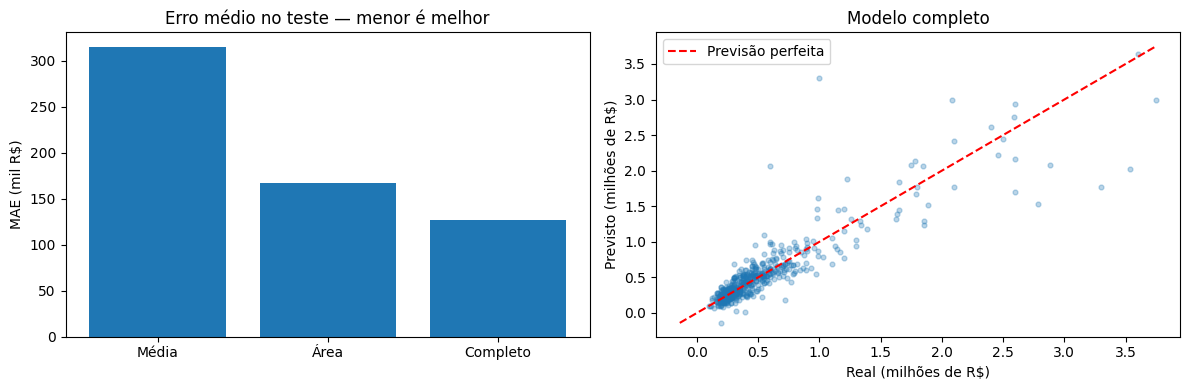

In [18]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 4))
eixos[0].bar(["Média", "Área", "Completo"], resultados["MAE (R$)"] / 1000)
eixos[0].set(title="Erro médio no teste — menor é melhor", ylabel="MAE (mil R$)")
eixos[1].scatter(y_teste / 1_000_000, previsoes / 1_000_000, alpha=0.3, s=12)
menor = min(y_teste.min(), previsoes.min()) / 1_000_000
maior = max(y_teste.max(), previsoes.max()) / 1_000_000
eixos[1].plot([menor, maior], [menor, maior], "r--", label="Previsão perfeita")
eixos[1].set(title="Modelo completo", xlabel="Real (milhões de R$)", ylabel="Previsto (milhões de R$)")
eixos[1].legend()
plt.tight_layout()
plt.show()

Pontos acima da linha tracejada indicam superestimação; abaixo, subestimação. A regressão pode prever valores negativos, pois não impõe limites à saída. Não vamos esconder essas previsões na avaliação.

Mesmo esta base mais organizada exige cuidados. O modelo não conhece acabamento, conservação ou andar. Um MAE menor não garante uma boa previsão para cada apartamento.

## 9. Prever o preço de outro apartamento
Vamos usar um exemplo de 70 m², dois quartos, dois banheiros, uma suíte e uma vaga. Informaremos também condomínio, lazer e bairro. Podemos alterar esses valores e executar novamente.

In [19]:
bairro_exemplo = contagens.loc[bairros_frequentes].idxmax()
novo_imovel = pd.DataFrame({
    "area": [70], "quartos": [2], "banheiros": [2], "suites": [1],
    "vagas": [1], "condominio": [500], "piscina": [1], "academia": [1],
    "quadra": [0], "bairro": [bairro_exemplo]
})

def reais(valor):
    return "R$ " + f"{valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

preco_estimado = modelo.predict(preparar_entradas(novo_imovel))[0]
display(novo_imovel)
print("Preço estimado:", reais(preco_estimado))

,area,quartos,banheiros,suites,vagas,condominio,piscina,academia,quadra,bairro
0,70,2,2,1,1,500,1,1,0,CID LIDER


Preço estimado: R$ 581.174,38


## 10. Formulário interativo
Execute a célula abaixo uma vez. Depois preencha os campos e clique em **Prever preço**. O botão usa o modelo já treinado.

Teste piscina, academia e quadra pelos seletores. Altere um campo por vez e compare a previsão completa com a previsão somente pela área. Nos bairros agrupados como `Outros`, o modelo não distingue cada localização.

Os campos numéricos, exceto condomínio, usam os limites observados no treino. Isso não garante que toda combinação seja representativa. Se a sessão do Colab reiniciar, execute as etapas anteriores novamente.

In [20]:
import ipywidgets as widgets
from google.colab import output
output.enable_custom_widget_manager()

rotulos = {"area": "Área (m²)", "quartos": "Quartos", "banheiros": "Banheiros",
           "suites": "Suítes", "vagas": "Vagas", "condominio": "Condomínio (R$)",
           "piscina": "Piscina", "academia": "Academia", "quadra": "Quadra"}
padroes = {"area": 70, "quartos": 2, "banheiros": 2, "suites": 1, "vagas": 1,
           "condominio": 500, "piscina": 1, "academia": 1, "quadra": 0}
estilo = {"description_width": "140px"}
campos = {}
for coluna in numericas:
    if coluna in ["piscina", "academia", "quadra"]:
        campos[coluna] = widgets.Dropdown(options=[("Não", 0), ("Sim", 1)],
            value=padroes[coluna], description=rotulos[coluna] + ":", style=estilo)
    else:
        minimo = 0 if coluna == "condominio" else int(X_treino[coluna].min())
        maximo = 10000 if coluna == "condominio" else int(X_treino[coluna].max())
        campos[coluna] = widgets.BoundedFloatText(value=padroes[coluna], min=minimo,
            max=maximo, step=1, description=rotulos[coluna] + ":", style=estilo) if coluna in ["area", "condominio"] else widgets.BoundedIntText(
            value=padroes[coluna], min=minimo, max=maximo, step=1,
            description=rotulos[coluna] + ":", style=estilo)
campos["bairro"] = widgets.Dropdown(options=categorias_bairro, value=bairro_exemplo,
    description="Bairro:", style=estilo, layout=widgets.Layout(width="430px", max_width="100%"))
botao = widgets.Button(description="Prever preço", button_style="success", icon="calculator")
resultado = widgets.HTML("<p>Preencha os campos e clique em <b>Prever preço</b>.</p>")

def prever_formulario(evento):
    imovel = pd.DataFrame({coluna: [campo.value] for coluna, campo in campos.items()})
    if imovel["suites"].iloc[0] > imovel["quartos"].iloc[0]:
        resultado.value = "<p>O número de suítes não pode ser maior que o número de quartos.</p>"
        return
    valor = modelo.predict(preparar_entradas(imovel))[0]
    valor_simples = modelo_metragem.predict(imovel[["area"]])[0]
    aviso = ""
    if valor < y_treino.min() or valor > y_treino.max():
        aviso = "<p>A previsão ficou fora da faixa de preços observada no treino. Interprete com cautela.</p>"
    if imovel["bairro"].iloc[0] == "Outros":
        aviso += "<p>Outros reúne bairros pouco representados ou inéditos.</p>"
    resultado.value = (
        "<div style='padding:16px;border:1px solid #16a34a;border-radius:8px'>"
        "<b>Preço estimado com características e bairro</b><br>"
        f"<span style='font-size:28px'>{reais(valor)}</span>"
        f"<p>Somente pela área: {reais(valor_simples)}</p>"
        "<small>Estimativa baseada em anúncios históricos de venda.</small>" + aviso + "</div>"
    )

botao.on_click(prever_formulario)
display(widgets.VBox([
    widgets.HTML("<h3>Simulador de preço de apartamentos em São Paulo</h3>"),
    *campos.values(), botao, resultado
]))

## Exercícios
1. Por que `unit`, o preço por m², não deve ser usado para prever o preço total?
2. Por que usamos a mediana calculada no conjunto de treino para preencher os valores ausentes de condomínio tanto no treino quanto no teste?
3. Qual variável tem maior correlação com preço? Isso prova causa e efeito?
4. Por que não atribuímos números 1, 2 e 3 aos bairros?
5. Qual das três abordagens teve menor MAE? Registre os valores em reais.
6. No formulário, altere apenas piscina de “Sim” para “Não”. Qual previsão mudou? Essa diferença comprova o efeito de uma piscina sobre o preço do imóvel?
7. Repita o teste com bairro, mantendo os demais campos.
8. Quais limitações impedem usar o resultado como avaliação atual de mercado?

### Fontes e recorte
- [Dataset — Apartamentos à venda na cidade de São Paulo](https://www.kaggle.com/datasets/jlgrego/apartamentos-venda-na-cidade-de-sao-paulo-sp). Original `dados_wgs.xlsx`, fornecido como `Apartamentos_SP_Original.xlsx` sem mudança de conteúdo. Atualização da publicação: abril de 2023; não equivale à confirmação da data exata de coleta.
- [Scikit-learn — LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html).
- [Pandas — get_dummies](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html).
- [Jupyter Widgets](https://ipywidgets.readthedocs.io/en/stable/examples/Widget%20List.html).

As regras de qualidade e a seleção de características são decisões didáticas explícitas. A base é de anúncios de apartamentos à venda.